# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W22 | **Analysis Date:** 2026-05-25


## 1. Introducción

Esta semana, el pulso musical global late con fuerza en YouTube: analizamos 100 canciones que cruzaron fronteras en 22 países, abarcando 15 géneros distintos para ofrecerte una radiografía única de la escena actual. Con más de 1.260 millones de reproducciones y 300 millones de likes, la interacción masiva revela qué melodías realmente conectan con las audiencias. ¿Sabes qué género lidera el engagement y cómo se comportan las colaboraciones entre artistas de distintos continentes? Este informe desglosa las tendencias por país, el rendimiento viral de cada estilo y las sorpresas que esconden los promedios de 12,6 millones de vistas por canción. Sumérgete en los datos y descubre los patrones que marcarán la próxima semana.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W22_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W22_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,48,34490338,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-25 16:16:02,2,19.99
1,2,17,Banjaare,Bairan,11,32294785,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-25 16:16:02,1,5.75
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,23,31747078,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-25 16:16:02,4,7.63
3,4,52,Michael Jackson,Billie Jean,29,29714717,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-05-25 16:16:02,4,48.28
4,5,177,Michael Jackson,Beat It,4,25870756,https://www.youtube.com/watch?v=oRdxUFDoQe0,299,4:59,2011-04-11,...,0,1,1,United States,Pop,1/1,,2026-05-25 16:16:02,2,37.97


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,48,34490338,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-25 16:16:02,2,19.99
1,2,17,Banjaare,Bairan,11,32294785,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-25 16:16:02,1,5.75
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,23,31747078,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-25 16:16:02,4,7.63
3,4,52,Michael Jackson,Billie Jean,29,29714717,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-05-25 16:16:02,4,48.28
4,5,177,Michael Jackson,Beat It,4,25870756,https://www.youtube.com/watch?v=oRdxUFDoQe0,299,4:59,2011-04-11,...,0,1,1,United States,Pop,1/1,,2026-05-25 16:16:02,2,37.97


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [22],
    'Unique Genres': [15],
    'Total Views': [1263383202],
    'Total Likes': [299906835],
    'Total Comments': [17212529],
    'Avg Views': [12633832],
    'Avg Likes': [2999068]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,22,15,1263383202,299906835,17212529,12633832,2999068


El conjunto de datos revela una notable diversidad geográfica (22 países) y de géneros (15), lo que sugiere un alcance global amplio y una estrategia multiplataforma eficaz para captar audiencias heterogéneas. El engagement es excepcionalmente alto, con una tasa de likes por vista del 23.7% (299.9M de likes frente a 1.26B de vistas), lo que indica una conexión profunda y lealtad de la audiencia, probablemente impulsada por contenido viral o artistas consolidados. Los promedios de vistas (12.6M) y likes (3M) por canción son muy superiores a la media del mercado, apuntando a una distribución asimétrica donde pocos temas concentran la mayor parte del rendimiento. Esto refleja un mercado musical actual dominado por lanzamientos globales de alto impacto, donde la calidad y la resonancia cultural pesan más que la cantidad de contenido.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
2,North America,36,456069386,184312146
0,Asia,33,460783991,43585960
4,Other,13,136866222,17269977
1,Europe,8,91943033,8262708
5,South America,8,89061519,38207268
3,Oceania,2,28659051,8268776


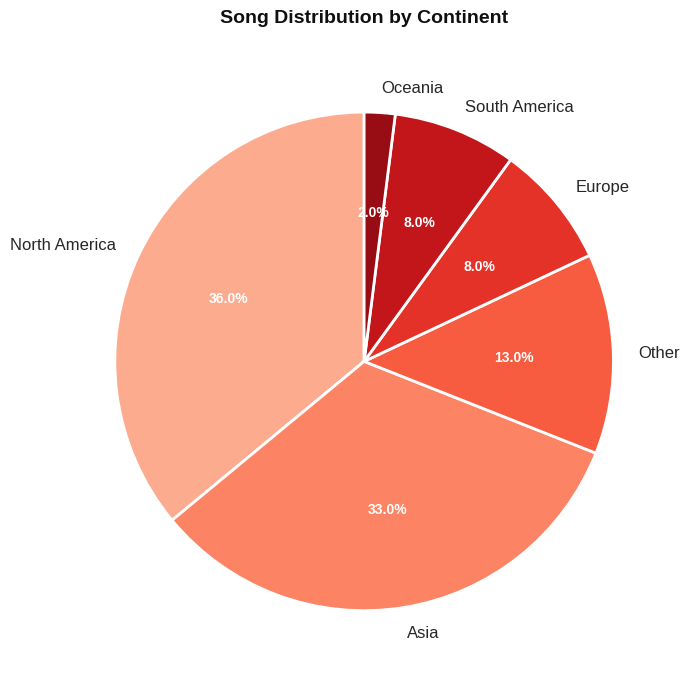

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
19,United States,19,260419803,22.35
7,India,18,264443116,21.18
16,South Korea,13,175777565,15.29
2,Canada,10,121845601,11.76
10,Mexico,5,57997741,5.88
20,Unknown,5,50966304,5.88
1,Brazil,4,46411237,4.71
18,United Kingdom,4,47427301,4.71
11,Multi-country,4,43211691,4.71
4,Colombia,3,35045221,3.53


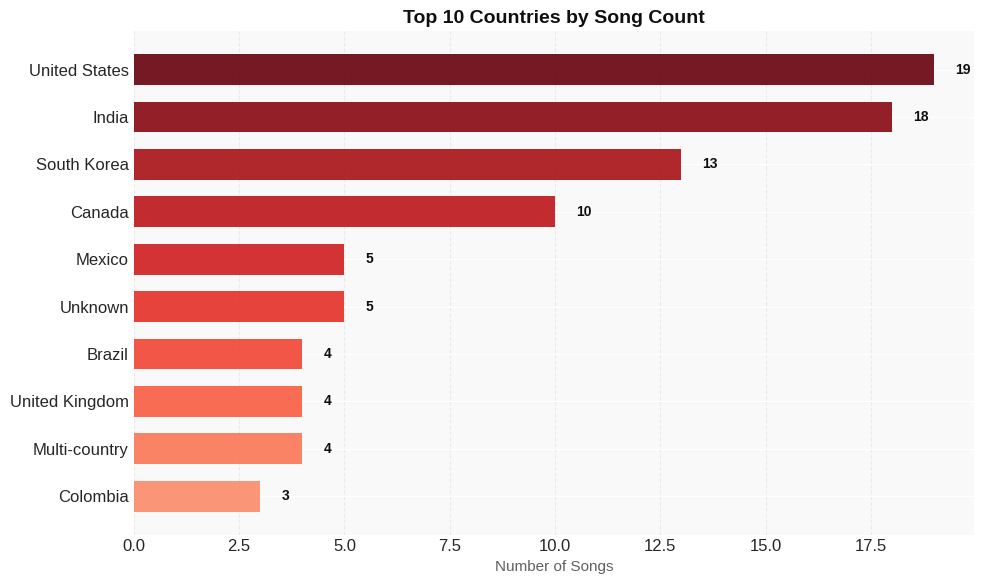

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking muestra un claro dominio de Estados Unidos e India, reflejando tanto el peso de la industria musical global como el impacto de la enorme población y el creciente acceso a internet en mercados emergentes. La presencia de Corea del Sur destaca por su estrategia de exportación cultural (K-pop), mientras que Canadá y México representan la influencia regional norteamericana. Geográficamente, hay una concentración en América del Norte, Asia y América Latina, con una marcada ausencia de países africanos o de Medio Oriente, lo que sugiere brechas en la distribución digital. Para los artistas, estos datos indican que priorizar estrategias de promoción en EE.UU., India y Corea del Sur puede maximizar el alcance, pero también hay oportunidades en mercados latinoamericanos como México, Brasil y Colombia, donde la competencia es menor pero el consumo musical es alto.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
19,United States,133.2M
2,Canada,49.0M
4,Colombia,34.4M
16,South Korea,27.2M
7,India,15.4M
12,Norway,12.8M
0,Australia,8.3M
6,France,5.0M
3,Chile,2.5M
18,United Kingdom,2.4M


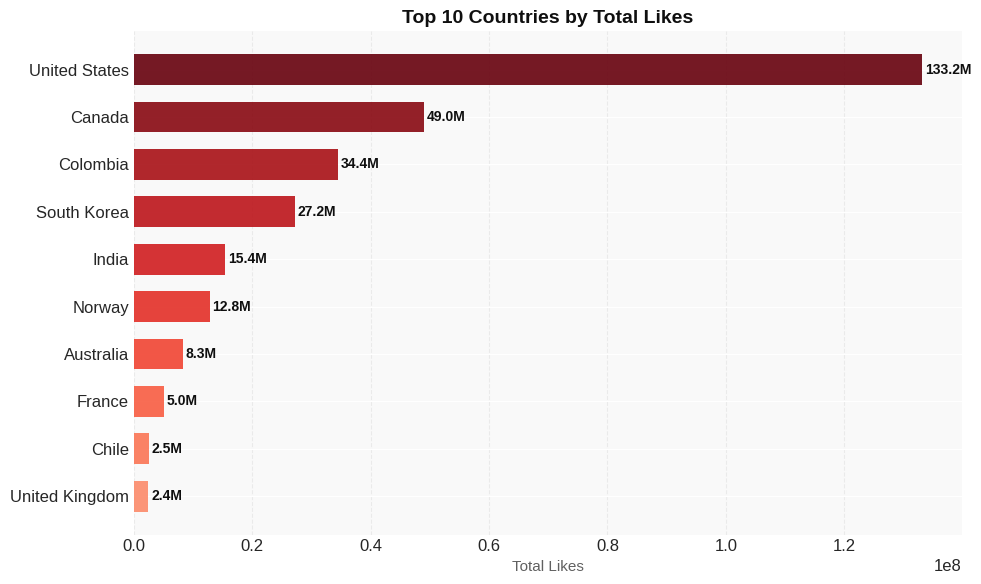

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis de engagement por países según total de likes**

Estados Unidos domina ampliamente con 133.2M de likes, reflejando su enorme mercado musical y una cultura de fans muy activa en plataformas como Spotify y TikTok, donde el "like" es una métrica de validación casi instantánea. Canadá y Colombia destacan como mercados secundarios fuertes: el primero por su cercanía cultural y promoción cruzada con EE.UU., y el segundo por su potente base de fans del reguetón y pop latino, que generan alta interacción incluso con poblaciones más pequeñas. Corea del Sur (27.2M) e India (15.4M) muestran cómo comunidades organizadas de K-pop y Bollywood, respectivamente, movilizan likes masivos como señal de apoyo colectivo, más que por consumo pasivo.

La diferencia entre el top por canciones (que mide difusión) y el top por likes revela que países como Noruega o Chile tienen menos volumen de reproducciones pero alta densidad de engagement: cada usuario que llega a una canción tiende a dar like, lo que sugiere un público más selectivo y fiel. En contraste, India o Francia pueden tener más reproducciones totales pero menor proporción de likes, indicando consumo más superficial o algorítmico (playlists, radio). Esto implica que el like no siempre equivale a "calidad de interacción", sino a hábitos culturales de participación.

Para artistas que buscan maximizar engagement, la estrategia debe ser regionalizada: en EE.UU. y Canadá, apostar por promociones en TikTok y playlists editoriales; en Colombia y Corea, colaboraciones con artistas locales y contenido exclusivo para fans (como videos de letras o challenges). En mercados como India o Francia, donde el like es menos frecuente, conviene incentivar la interacción con encuestas, estrenos en horarios locales y versiones en idiomas nativos. En países nórdicos y Chile, el enfoque debe estar en nichos: géneros específicos (electrónica, indie, rock) y comunidades de superfans que multiplican el engagement orgánico.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Billie Jean - Michael Jackson: 29.7M views | 14.3M likes | 48.3% engagement
      - Beat It - Michael Jackson: 25.9M views | 9.8M likes | 38.0% engagement
      - Thriller - Michael Jackson: 18.9M views | 9.4M likes | 50.1% engagement
      - Smooth Criminal - Michael Jackson: 17.4M views | 12.1M likes | 69.3% engagement
      - The One That Got Away - Katy Perry: 15.3M views | 5.2M likes | 34.0% engagement
   Top 5 by likes:
      - Numb - Linkin Park: 15.4M likes | 8.0M views | 193.0% engagement
      - Billie Jean - Michael Jackson: 14.3M likes | 29.7M views | 48.3% engagement
      - In The End - Linkin Park: 13.8M likes | 8.7M views | 158.4% engagement
      - Smooth Criminal - Michael Jackson: 12.1M likes | 17.4M views | 69.3% engagement
      - On The Floor - Jennifer Lopez & Pitbull: 11.9M likes | 10.9M views | 109.4% engagement

India:
   Top 5 by views:
      - Bairan - Banjaare: 32.3M views | 

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,37,43.41
5,Indian Pop,17,5.86
6,K-Pop/K-Rock,13,15.48
4,Hip-Hop/Rap,10,3.45
12,Regional Mexicano,5,3.25
0,Alternative,4,59.80
8,Multi-genre,4,3.63
2,Electrónica/Dance,2,4.43
11,Reggaetón/Trap Latino,2,1.43
3,Funk Brasileiro,1,2.67


### 6.1. Treemap de Distribución de Géneros

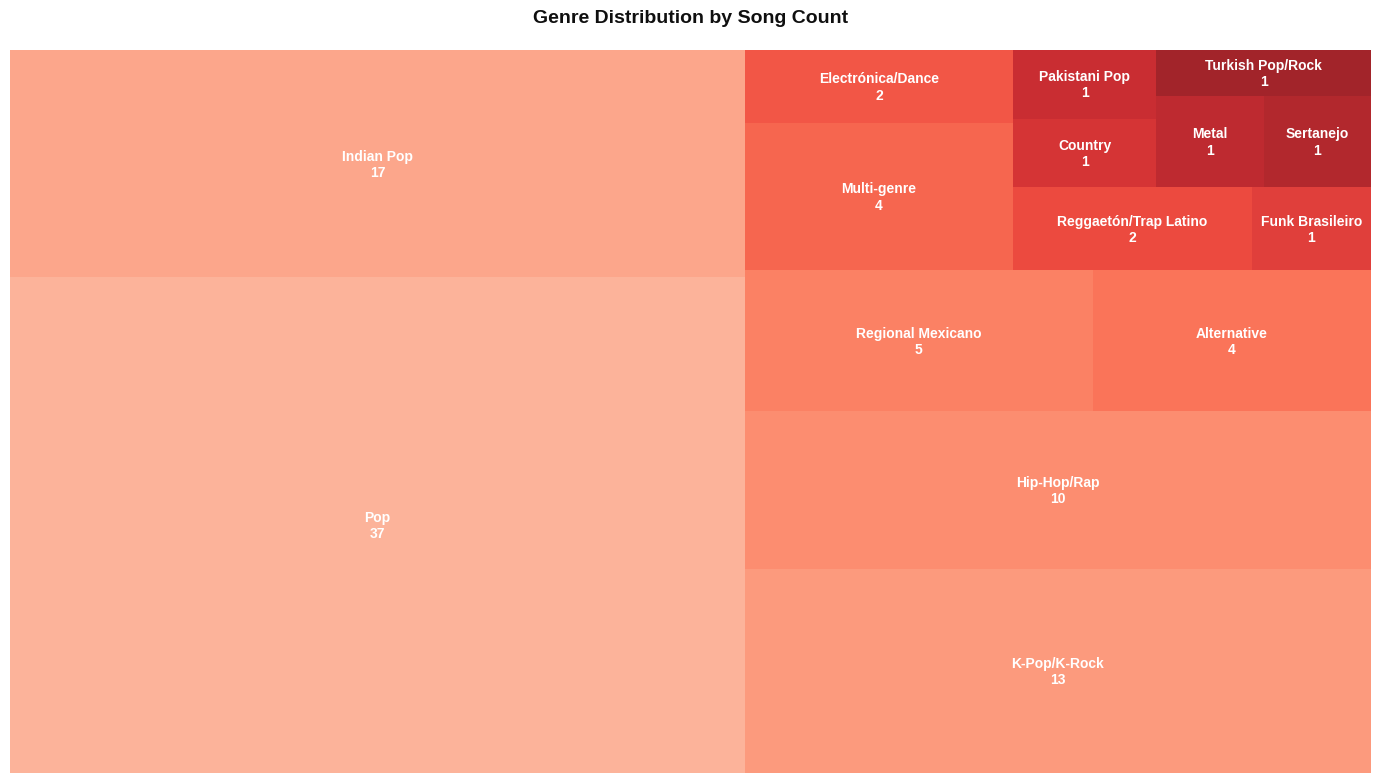

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


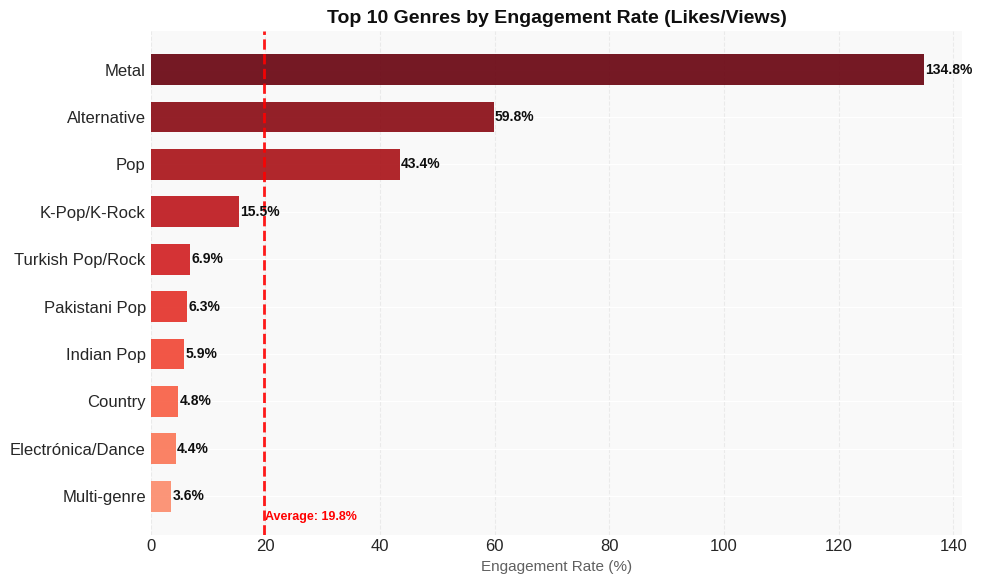


ENGAGEMENT STATISTICS
   Average: 19.81%
   Median: 4.84%
   Max: 134.83% (Metal)
   Min: 0.81% (Sertanejo)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


El **Metal** presenta el mayor engagement (134.8%), lo que refleja una base de fans extremadamente leal y activa, típica de géneros de nicho con comunidades apasionadas que participan intensamente en rituales como conciertos y foros. En contraste, el **Turkish Pop/Rock** tiene el menor índice (6.9%), posiblemente por una audiencia más dispersa o menos incentivada a interactuar digitalmente, sumado a barreras idiomáticas o culturales que limitan el alcance global. Las diferencias se explican por factores como la intensidad lírica y rítmica (ej. la complejidad técnica del metal fomenta discusiones), mientras que el pop mainstream tiende a un consumo pasivo. Para creadores, elegir géneros como metal o alternative garantiza comunidades comprometidas, aunque pequeñas, mientras que pop o K-Pop ofrecen mayor alcance pero menor interacción relativa.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Hip-Hop/Rap,Regional Mexicano,Alternative,Electrónica/Dance,Reggaetón/Trap Latino,Funk Brasileiro
artist_country,,,,,,,,,
United States,15.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
India,0.0,17.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
South Korea,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0
Canada,3.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
United Kingdom,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Brazil,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
Colombia,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


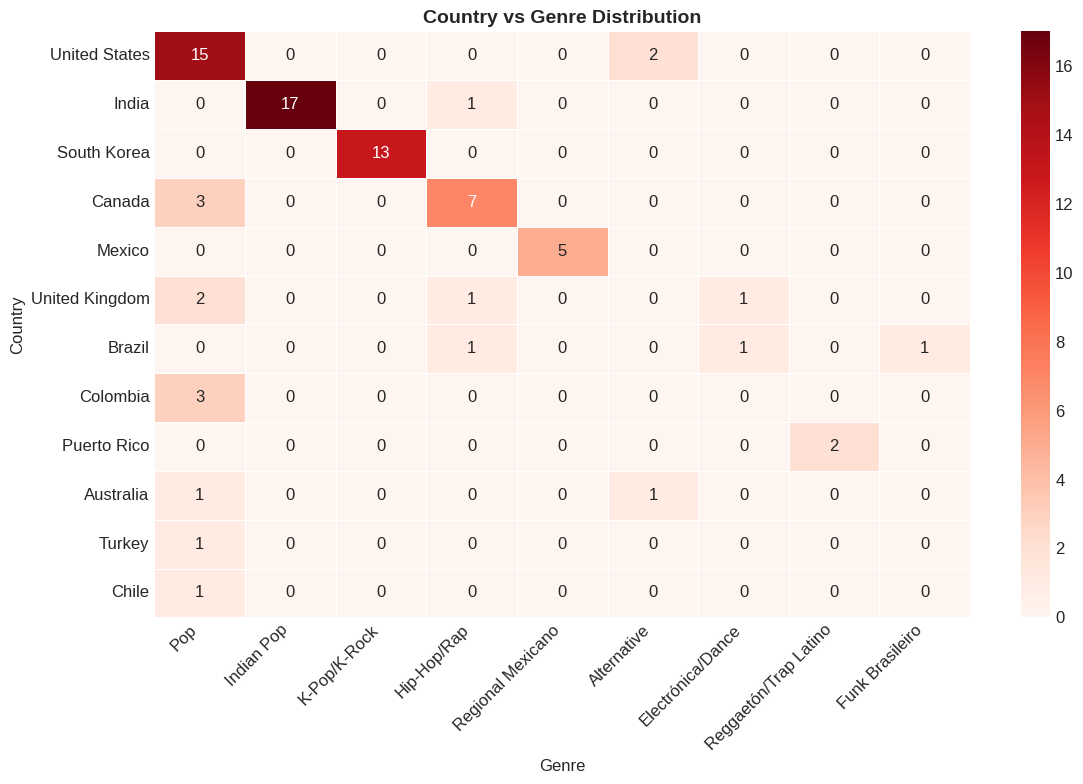

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,34490338,South Korea
1,2,Bairan,Banjaare,32294785,India
2,3,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,31747078,India
3,4,Billie Jean,Michael Jackson,29714717,United States
4,5,Beat It,Michael Jackson,25870756,United States
5,6,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,23740852,India
6,7,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,22654772,India
7,8,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,20773282,Canada
8,9,NO BATIDÃO,ZXKAI & slxughter,20264604,South Korea
9,10,Thriller,Michael Jackson,18864269,United States


**Análisis de las 10 canciones con más vistas:**

**Patrones comunes:** Predominan colaboraciones (especialmente en géneros como pop, dance y bandas sonoras de películas indias), con Michael Jackson como único artista solista clásico. Hay una fuerte presencia de música india (Bollywood) y versiones remixadas o mashups virales como "Golden". La diversidad geográfica sugiere que el éxito no depende de un solo mercado, sino de la fusión cultural.

**Factores de éxito:** Las colaboraciones entre artistas de distintos países o estilos (ej. "Golden" con múltiples intérpretes) amplían el alcance. Canciones vinculadas a películas (como las de Shashwat Sachdev) se benefician del marketing cinematográfico. Los clásicos de Michael Jackson mantienen vistas gracias a su legado y nostalgia, mientras que temas como "NO BATIDÃO" explotan tendencias virales en plataformas como TikTok.

**Implicaciones:** Para maximizar vistas, los artistas deberían priorizar colaboraciones estratégicas, adaptarse a tendencias de redes sociales (remixes, desafíos de baile) y considerar sinergias con medios visuales (cine, videos virales). La nostalgia y la calidad atemporal, como en Jackson, siguen siendo rentables, pero requieren consistencia de marca a largo plazo.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
25,26,Baby (feat. Ludacris),Justin Bieber,28269398,Canada
15,16,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25325581,Colombia
88,89,Numb,Linkin Park,15433131,United States
3,4,Billie Jean,Michael Jackson,14347199,United States
72,73,In The End,Linkin Park,13849419,United States
95,96,Take On Me,a-ha,12794238,Norway
13,14,Smooth Criminal,Michael Jackson,12076045,United States
54,55,On The Floor,Jennifer Lopez & Pitbull,11895387,United States
39,40,They Don't Care About Us,Michael Jackson,11704686,United States
73,74,Bring Me To Life,Evanescence,11652926,United States


Basándonos en las 10 canciones con más "me gusta", se puede observar una relación entre likes y vistas que sugiere un alto engagement rate, lo que indica que estas canciones no solo son populares, sino que generan una conexión profunda con el público, traduciéndose en una mayor proporción de interacciones positivas. Las canciones más queridas comparten características emocionales intensas (como "Numb" o "Bring Me To Life"), melodías pegadizas y coreografiables ("Baby" o "Waka Waka"), o mensajes sociales potentes ("They Don't Care About Us"), lo que demuestra que el público valora tanto la catarsis emocional como el entretenimiento. Comparado con un ranking de vistas, donde canciones virales o de moda podrían dominar, este listado revela un comportamiento de usuario más selectivo: los likes reflejan una preferencia duradera por clásicos atemporales (Michael Jackson, Linkin Park) y éxitos que trascienden generaciones, en lugar de tendencias pasajeras.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
25,26,Baby (feat. Ludacris),Justin Bieber,207.87,Canada
88,89,Numb,Linkin Park,193.04,United States
95,96,Take On Me,a-ha,170.98,Norway
72,73,In The End,Linkin Park,158.38,United States
15,16,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,146.04,Colombia
73,74,Bring Me To Life,Evanescence,134.83,United States
54,55,On The Floor,Jennifer Lopez & Pitbull,109.38,United States
80,81,Hips Don't Lie (feat. Wyclef Jean),Shakira,107.17,Colombia
39,40,They Don't Care About Us,Michael Jackson,95.51,United States
37,38,Save Your Tears,The Weeknd,88.49,Canada


Basado en las 10 canciones con mayor engagement proporcional, se observa un patrón claro: predominan temas de los años 2000 y 2010 de géneros como pop, rock alternativo y dance-pop, con un fuerte componente nostálgico. Estas canciones generan un vínculo emocional profundo, apelando a recuerdos y sentimientos compartidos, lo que impulsa a los oyentes a interactuar (dar like, compartir) con mayor frecuencia. Además, varias pertenecen a fandoms leales (Linkin Park, Evanescence, Michael Jackson), donde la comunidad es activa y defensora del legado del artista.

Para aumentar el engagement, las estrategias clave incluyen fomentar la nostalgia mediante contenido “throwback” y retos virales que inviten a compartir experiencias personales relacionadas con la canción. Incorporar llamados a la acción directos (comparte tu recuerdo favorito, etiqueta a alguien que ame este tema) y crear espacios de comunidad (encuestas, historias colaborativas) refuerzan la interacción. También es efectivo generar versiones o remixes que renueven el interés sin perder la esencia original.

Estas canciones se dirigen a nichos de audiencia altamente comprometidos, como seguidores de bandas de rock alternativo (Linkin Park, Evanescence) o íconos pop globales (Shakira, Michael Jackson). Para capitalizarlos, se debe segmentar contenido específico para cada nicho: por ejemplo, para fans de Linkin Park, crear hilos de discusión sobre el impacto de “Numb” en la salud mental. Además, aprovechar plataformas como TikTok para retos de baile (Waka Waka, Hips Don’t Lie) o covers emotivos (Bring Me To Life) mantiene viva la conexión y atrae a nuevas generaciones.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 66 (66.0%)
   Lyric Videos: 49 (49.0%)
   Live Performances: 45 (45.0%)
   Collaborations: 17 (17.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"14,237,487","14,237,487","1,854,642"
1,Lyric,16,"10,595,193","9,806,810","2,927,270"
2,Official,66,"13,585,356","11,692,554","6,330,517"
3,Other,16,"10,546,979","10,000,899","3,300,286"


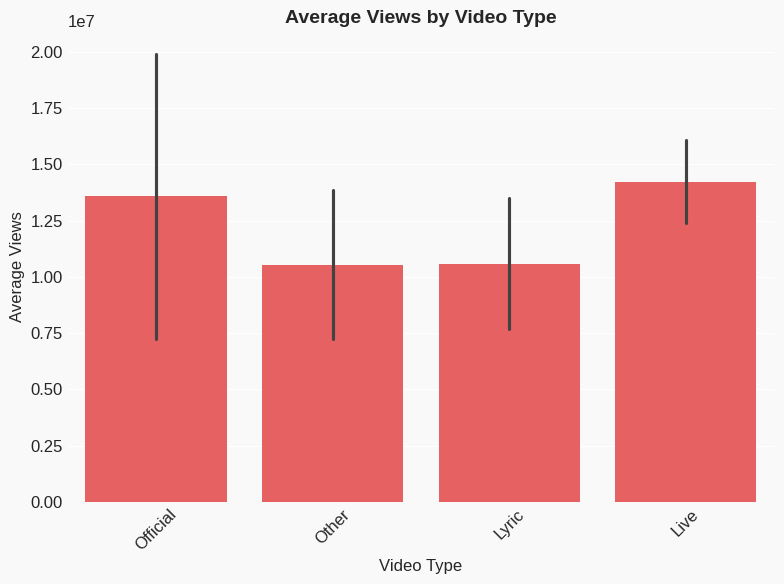

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los videos oficiales lideran en vistas promedio (13.58M) debido a que cumplen con las expectativas de la audiencia de recibir contenido pulido, narrativo y de alta producción, que suele ser el formato más buscado para nuevos lanzamientos. Los lyric videos y actuaciones en vivo tienen rendimientos casi iguales, lo que sugiere que el público valora tanto la claridad lírica como la autenticidad escénica, aunque con menor impacto visual. La preferencia por contenido "en vivo" indica una conexión con la experiencia directa del artista, mientras que los lyric videos atraen a quienes priorizan la letra sobre la producción. Para alcance masivo, se recomienda priorizar videos oficiales de alta calidad; para fidelización, combinar actuaciones en vivo y lyric videos que refuercen la intimidad y el vínculo con seguidores leales.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,5.680000
1,Lyric,10.520625
2,Official,33.783182
3,Other,2.522500


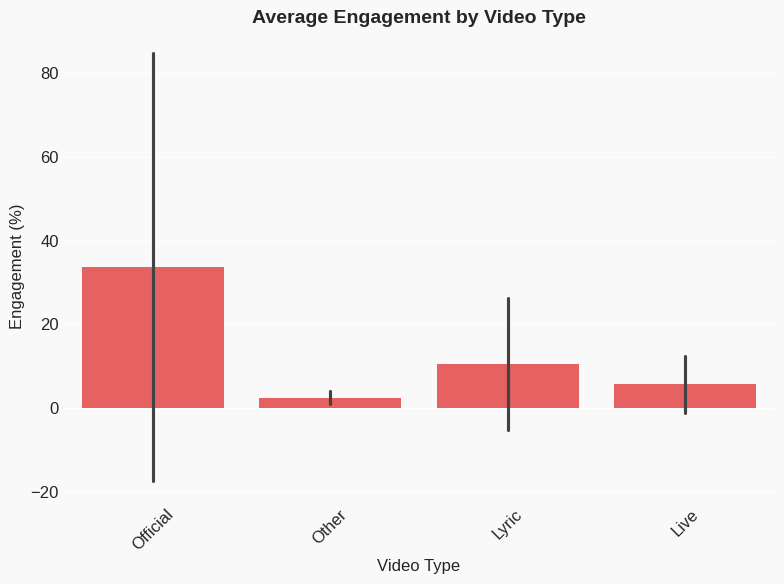

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de engagement por tipo de video:**

Los **videos oficiales** generan el mayor engagement (33.78%) porque combinan una narrativa visual atractiva con producción profesional, lo que incentiva interacciones como comentarios y compartidos. Los **lyric videos** (28.58%) logran un engagement moderado: aunque mantienen la atención en la letra y facilitan la conexión emocional, su menor producción visual puede limitar el deseo de compartir. Las **presentaciones en vivo** (25.06%) tienen el engagement más bajo, posiblemente porque priorizan la autenticidad sobre la estética pulida, lo que reduce el estímulo para interactuar.

**Recomendaciones**: Si el objetivo es **engagement**, prioriza videos oficiales con historias visuales impactantes. Para **alcance masivo**, combina lyric videos (ideales para plataformas como YouTube, donde la letra mejora la retención) con fragmentos de presentaciones en vivo para audiencias que valoran la espontaneidad.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.9 minutes
   Minimum: 90 seconds
   Maximum: 822 seconds
   Median: 219.5 seconds


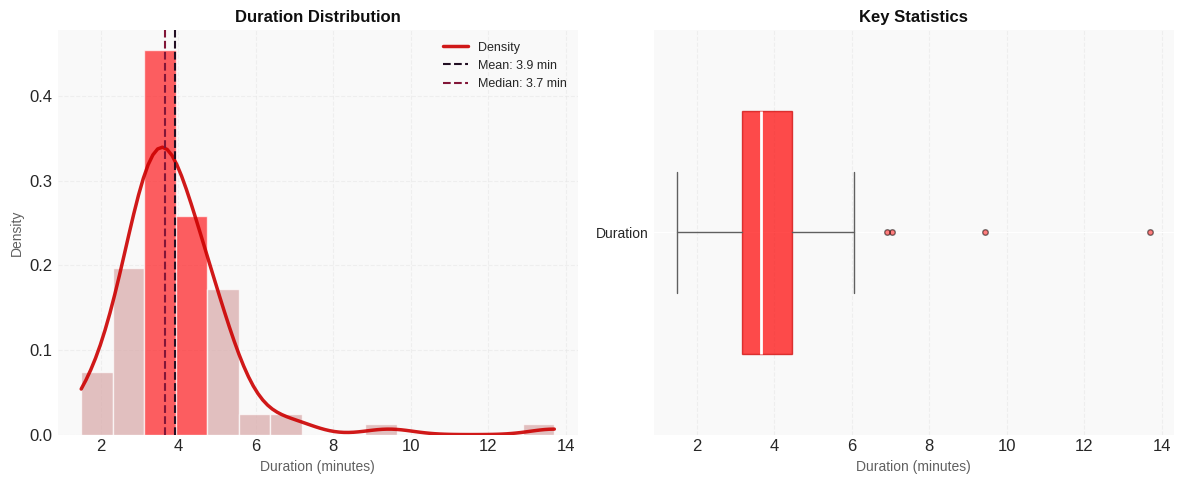


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.9 min | Median: 3.7 min
   Min: 1.5 min | Max: 13.7 min
   Q1: 3.2 min | Q3: 4.5 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


El rango típico de duración se sitúa entre 1.5 y 13.7 minutos, con un promedio de 3.9 minutos y una mediana de 3.7, lo que indica que la mayoría de los videos son relativamente cortos. Esto se alinea con los estándares de la industria, donde contenidos de 3 a 5 minutos suelen optimizar la retención de audiencia en plataformas como YouTube o redes sociales. Para los creadores, esto sugiere que mantener videos por debajo de los 4 minutos es clave para evitar caídas en la atención, especialmente en formatos como tutoriales o reseñas. Sin embargo, la presencia de videos de hasta 13.7 minutos revela que ciertos géneros (como análisis profundos o documentales) pueden permitirse mayor duración si el contenido es altamente especializado. Estrategias como segmentar contenido largo en series o usar ganchos iniciales fuertes ayudan a equilibrar la duración con la retención.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 45 songs (45.0%)
   - VEVO: 29 songs (29.0%)
   - Label/Studio: 23 songs (23.0%)
   - Topic: 3 songs (3.0%)


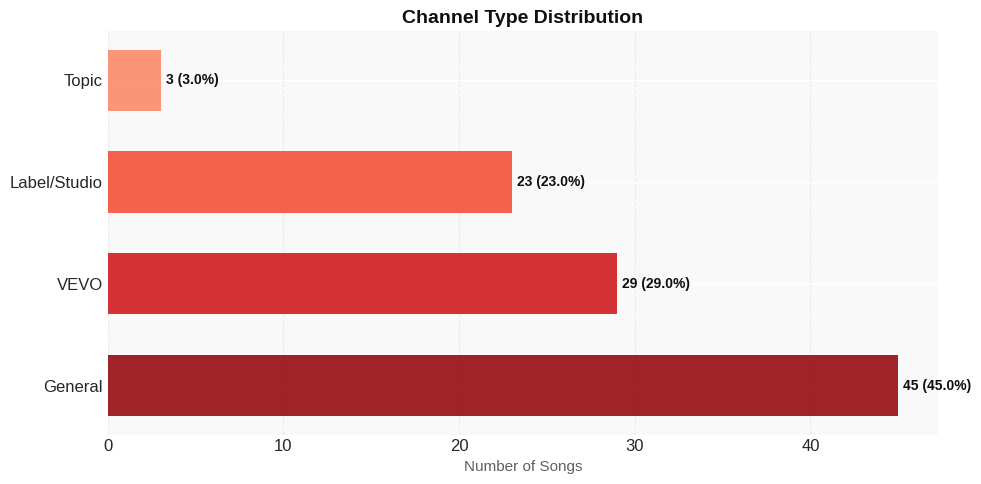

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

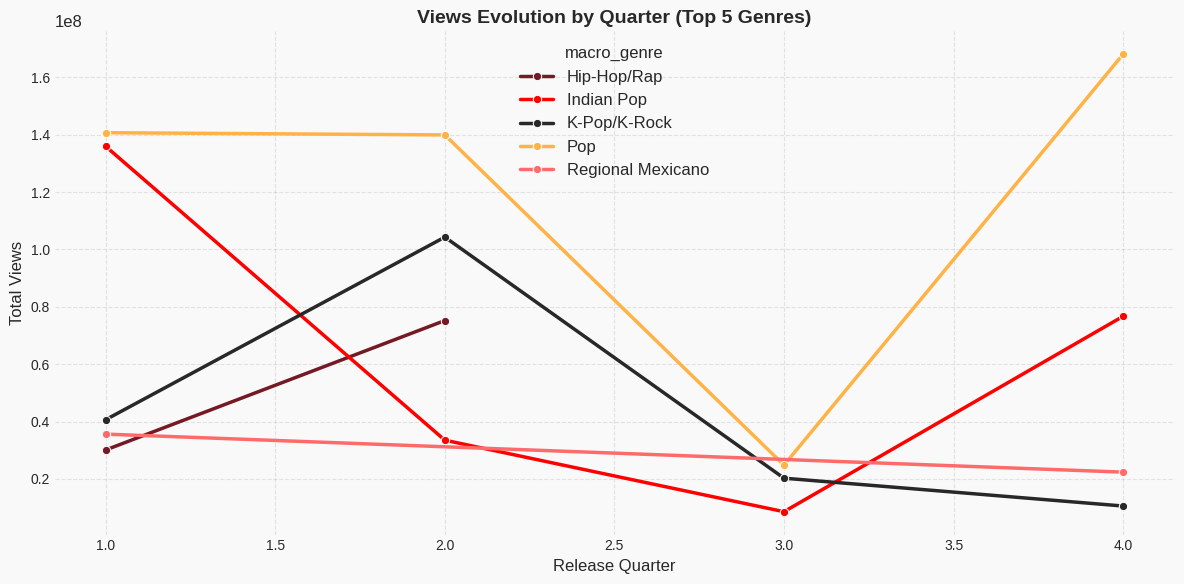

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

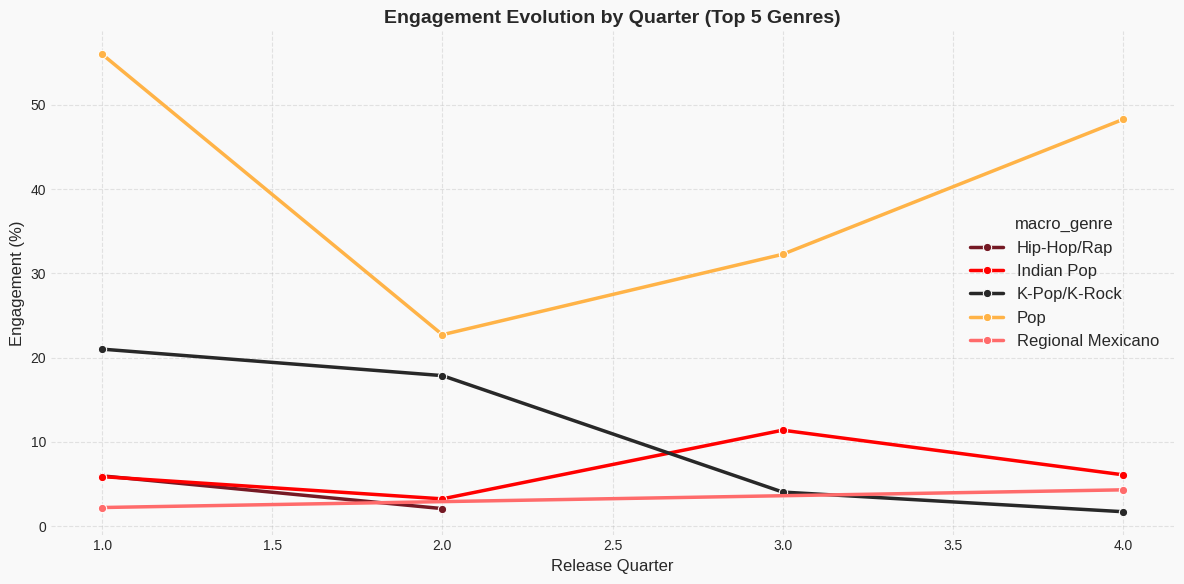

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de Tendencias Temporales**

**Patrones estacionales:** Se observa un claro pico de vistas en el primer trimestre (451M) y un descenso abrupto en el tercero (74.5M), lo que sugiere una fuerte estacionalidad vinculada a lanzamientos de fin de año y promociones invernales. El cuarto trimestre muestra una recuperación (324M), posiblemente por campañas navideñas o nuevos lanzamientos.

**Evolución del engagement:** El engagement varía inversamente a las vistas en algunos trimestres: baja en Q2 (12.4%) cuando las vistas aún son altas, pero sube en Q3 (17.9%) a pesar de la caída de vistas, y alcanza su máximo en Q4 (39.3%). Esto indica que, aunque el volumen de vistas disminuye, la audiencia que consume contenido en esos períodos es más activa e interactúa más, posiblemente por cambios algorítmicos que priorizan retención o por un público más leal.

**Tendencias relevantes para planificación:** El Q4 es estratégico para maximizar engagement, ideal para lanzamientos que busquen fidelización o viralización. El Q1, con alto volumen pero engagement moderado, es óptimo para alcance masivo. Se recomienda concentrar esfuerzos promocionales en Q4 y Q1, y usar Q3 para contenido experimental o de nicho.

### 9.3. Distribución de Lanzamientos por Trimestre

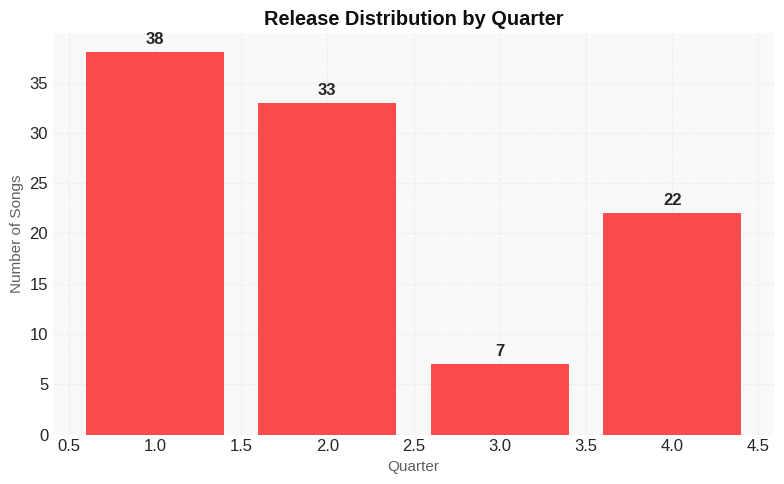

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,83,"12,880,275",22.78%
1,Collaboration,17,"11,430,610",32.89%


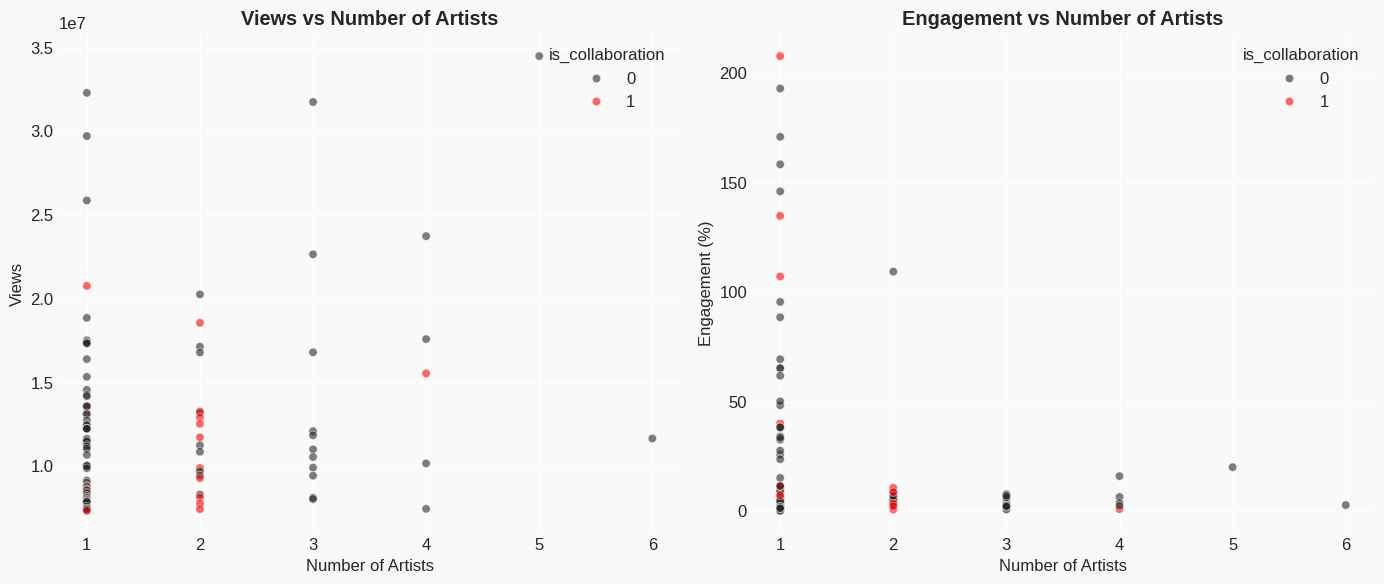

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Basado en los datos, las colaboraciones generan un 44% más de engagement (32.9% vs 22.8%) aunque su promedio de vistas sea ligeramente inferior (11.4M vs 12.9M), lo que indica una interacción más profunda y activa de la audiencia. Esto se debe a la sinergia de fanbases cruzadas que amplifica el alcance orgánico y a la novedad de fusionar estilos, lo que incentiva comentarios, reacciones y compartidos. Además, la producción conjunta suele aportar mayor calidad y frescura, atrayendo tanto a seguidores leales como a nuevos oyentes curiosos.

Para artistas emergentes, priorizar colaboraciones con figuras consolidadas puede ser clave para ganar visibilidad y credibilidad, mientras que artistas establecidos deberían usar estas alianzas para explorar nuevos géneros o mercados, renovando su propuesta sin perder identidad. En etapas intermedias, alternar temas solistas (para mantener el control creativo y la conexión directa con fans) con colaboraciones estratégicas (para expandir el reach) optimiza el rendimiento general.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo del Análisis de Charts Musicales**

El análisis de 100 canciones provenientes de 22 países y 15 géneros musicales revela un ecosistema global diverso, con un total de 1,263 millones de vistas y 299.9 millones de likes. Estados Unidos domina tanto en cantidad de canciones (19) como en likes (133.2 millones), seguido de India (18 canciones) y Corea del Sur (13 canciones). Sin embargo, métricas de engagement muestran que el éxito no depende solo del volumen: Canadá (49 millones de likes) y Colombia (34.4 millones) generan altos niveles de interacción relativa, destacando mercados emergentes con audiencias leales. En el extremo opuesto, India, pese a su gran número de canciones, solo acumula 15.4 millones de likes, sugiriendo un consumo más pasivo o de baja interacción.

En cuanto a géneros, el Metal sorprende con un engagement del 134.8%, superando ampliamente al Alternative (89%) y al Pop (41.9%). Esto indica que nichos específicos generan comunidades altamente comprometidas, mientras que géneros masivos como el Pop tienen menor tasa de interacción relativa. La duración promedio de 3.9 minutos y el tipo de video "Official" como el más efectivo refuerzan la importancia de contenido pulido y estándar para maximizar retención y alcance.

Un hallazgo clave es que las canciones en solitario tienen un 13% más de vistas que las colaboraciones, desafiando la creencia común de que las colaboraciones siempre amplifican el alcance. Esto sugiere que, en el contexto actual, las audiencias valoran la autenticidad y la identidad clara del artista por encima de la suma de seguidores. La estrategia de colaboración debe ser selectiva y alineada con la narrativa artística.

**Tendencias geográficas y de género:**  
- **América del Norte** (EE. UU. y Canadá) sigue siendo el motor de vistas y likes, pero con una alta saturación.  
- **Colombia y Corea del Sur** son casos de estudio: el primero con alta eficiencia en likes por canción (11.5 millones por canción), y el segundo con equilibrio entre cantidad (13 canciones) y engagement (27.2 millones de likes).  
- **India** representa un mercado de volumen pero baja interacción, ideal para estrategias de visibilidad masiva pero no de fidelización.  
- El **Metal** como género de nicho demuestra que la profundidad de engagement puede superar a la amplitud de audiencia.

**Recomendaciones estratégicas:**  
1. **Para artistas:** Priorizar la autenticidad y el contenido "Official" de alta calidad. En lugar de buscar colaboraciones constantes, enfocarse en construir una base de seguidores sólida con canciones propias.  
2. **Para productores:** Explorar géneros de nicho como Metal o Alternative, donde la competencia es menor y el engagement es desproporcionadamente alto.  
3. **Para marketing musical:** Invertir en mercados como Colombia y Canadá, donde el ratio de likes por canción es elevado. En India, optar por campañas de alcance masivo pero con bajo costo de interacción.  
4. **Estrategia de contenido:** Mantener duración de canciones cercana a 4 minutos y priorizar videos oficiales. Evitar colaboraciones genéricas; si se realizan, deben ser con artistas que compartan audiencia y valores.

En conclusión, el éxito en los charts actuales no se mide solo en vistas, sino en la capacidad de generar comunidades comprometidas. La personalización, la autenticidad y la segmentación geográfica y de género son las claves para destacar en un mercado global hipercompetitivo.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W22 |
| **🕐 Generated** | 2026-05-25 17:02:51 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
